In [11]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.ticker as ticker

In [12]:
simulator = AerSimulator()

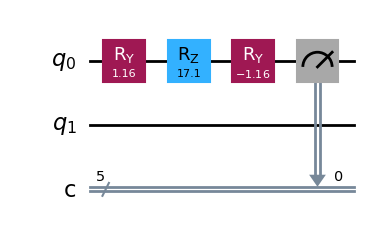

In [13]:
#Drawing the circuits for nu_e-->nu_e survival

#Assigning parameter values
theta=0.58
Dm2=7.49*10**-5 #eV^2
hbar= 6.582e-16 #eV.s
c=3e8 #m/s
L= 180e3 #Kamland baseline=180km converted to m
t=L/c #s
E_values= np.arange(2, 12.01, 0.01) # Energy range 2 MeV to 12 MeV
E=E_values[0]
omega=Dm2/(2*E*1e6*hbar) # Energy converted to eV
    
# implement the circuit

qc = QuantumCircuit(2, 5) # I took 2 qbits for 2 mass eigenststes. Initially both the qbits are at |0> which is nu_1. When we need to prepare nu_2, we will operate X gate on qbit1.

qc.ry(2*theta,0) # rotation matrix on y-axis = 2-D PMNS... prepares |nu_e>
qc.rz(omega*t,0) # Applying time evolution on nu_e
qc.ry(-2*theta,0) #reversing transformation to measure in flavour basis
qc.measure(0, 0)
    
qc.draw(output='mpl')
#plt.show()



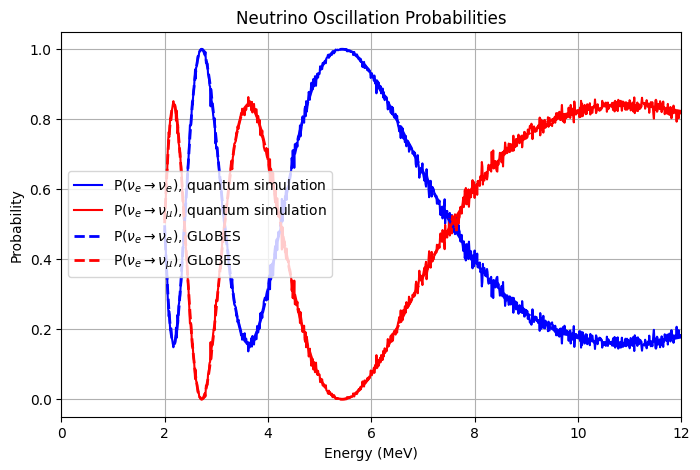

In [21]:
# Lists to store energy values and probabilities
E_list = []
P_nue_list = []
P_numu_list = []

for E in E_values:
    omega=Dm2/(2*E*1e6*hbar) #energy converted to eV
    
    # implement the circuit

    qc = QuantumCircuit(2, 5) # I took 2 qbits for 2 mass eigenststes. Initially both the qbits are at |0> which is nu_1. When we need to prepare nu_2, we will operate X gate on qbit1.

    qc.ry(2*theta,0) # rotation matrix on y-axis = 2-D PMNS... prepares |nu_e>
    qc.rz(omega*t,0) # Applying time evolution on nu_e
    qc.ry(-2*theta,0) #reversing transformation to measure in flavour basis
    qc.measure(0, 0)#measues in flavour basis
    ##### Run the circuit#######
    pqc = transpile(qc, simulator)
    job = simulator.run(qc, shots=1024)
    job_result = job.result()
    counts = job_result.get_counts()
    probability_nue=counts.get('00000',0)/1024 #nu_e-->nu_e survival probability
    probability_numu=counts.get('00001',0)/1024 #nu_e-->nu_mu pscillation probability

    # Store values
    E_list.append(E)
    P_nue_list.append(probability_nue)
    P_numu_list.append(probability_numu)

    
    #print (E/1e6, probability_nue, probability_numu)
     ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    #probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E / 1e6:.2f} MeV -> Probability: {probability}")
# Load the classical GLoBES results from the file
glb_E, glb_P_nue, glb_P_numu = np.loadtxt("prob_nue_numu_Kamland.dat", unpack=True)


# Plot the probabilities
plt.figure(figsize=(8, 5))

# Plot quantum simulation results
plt.plot(E_list, P_nue_list, label=r'P($\nu_e \to \nu_e$), quantum simulation', linestyle='-', color='blue')
plt.plot(E_list, P_numu_list, label=r'P($\nu_e \to \nu_\mu$), quantum simulation', linestyle='-', color='red')

# Plot classical GLoBES results from the data file
plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_e \to \nu_e$), GLoBES')
plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_e \to \nu_\mu$), GLoBES')
# Fix the x-axis range
plt.xlim(0, 12)  # Set range explicitly

# Fix x-axis formatting to avoid scientific notation
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}"))


# Labels and title
plt.xlabel("Energy (MeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities")
plt.legend()
plt.grid()
plt.show()
    
   